# Controlled-Unitary: built-in `.control()` vs manual Kronecker construction

Isolates a single ancilla-controlled collision-style unitary and compares the two construction paths used in `qlbm/physics.py`:

- **built-in**: build the base gate on `n` qubits, then call `.control(ctrl_state=...)` to lift it to `n+1` qubits.
- **manual**: build the full `2^(n+1) × 2^(n+1)` controlled matrix via Kronecker projections (`kron(U, |0⟩⟨0|) + kron(I, |1⟩⟨1|)`) and wrap it in a single `UnitaryGate`.

Both paths get compiled with the same transpiler settings. We record:
- construction time (Python-side)
- transpilation time (to IBM Eagle basis `{rz, sx, x, cx}`)
- transpiled gate count and depth
- end-to-end simulation runtime on Aer Statevector

Both the diagonal case (plain collision) and the general-unitary case (collision + boundary conditions, SVD-decomposed) are tested.

In [1]:
%load_ext autoreload
%autoreload 2

import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import DiagonalGate, UnitaryGate
from qiskit_aer import StatevectorSimulator

from qlbm.physics import get_collision_diagonal, decompose_matrix_svd

In [2]:
BASIS_GATES = ['rz', 'sx', 'x', 'cx']
simulator   = StatevectorSimulator()

PROJ_0 = np.array([[1, 0], [0, 0]], dtype=complex)
PROJ_1 = np.array([[0, 0], [0, 1]], dtype=complex)


def count_gates(circuit: QuantumCircuit) -> int:
    return sum(1 for instr in circuit.data if instr.operation.name != 'reset')


def time_it(fn, *args, repeats: int = 1, **kwargs):
    """Run `fn` `repeats` times, return (min_seconds, result_of_last_call)."""
    best = float('inf')
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn(*args, **kwargs)
        dt = time.perf_counter() - t0
        if dt < best:
            best = dt
    return best, result


def build_builtin(base_gate, n_target: int):
    """Approach A: use Qiskit's .control() on the base gate."""
    qc = QuantumCircuit(n_target + 1)
    ancilla   = n_target
    targets   = list(range(n_target))
    qc.append(base_gate.control(ctrl_state='0'), [ancilla] + targets)
    return qc


def build_manual(U: np.ndarray, n_target: int):
    """Approach B: assemble the full controlled matrix, wrap in a single UnitaryGate.

    Mirrors `collision_nonuniform` in qlbm.physics for the SVD path.
    """
    identity   = np.eye(U.shape[0], dtype=complex)
    controlled = np.kron(U, PROJ_0) + np.kron(identity, PROJ_1)
    qc = QuantumCircuit(n_target + 1)
    ancilla   = n_target
    targets   = list(range(n_target))
    qc.append(UnitaryGate(controlled), [ancilla] + targets)
    return qc


def measure(base_gate, U: np.ndarray, n_target: int, runtime_repeats: int = 3):
    """Run both approaches once, return a dict of timings/sizes."""
    row = {'n_target_qubits': n_target, 'total_qubits': n_target + 1}

    # --- Approach A: built-in .control() ---
    t_build_a, qc_a      = time_it(build_builtin, base_gate, n_target)
    t_trans_a, trans_a   = time_it(transpile, qc_a, basis_gates=BASIS_GATES)
    t_sim_a, _           = time_it(lambda: simulator.run(transpile(qc_a, simulator)).result(),
                                    repeats=runtime_repeats)
    row.update({
        'builtin_build_s':   t_build_a,
        'builtin_transp_s':  t_trans_a,
        'builtin_gates':     count_gates(trans_a),
        'builtin_depth':     trans_a.depth(),
        'builtin_runtime_s': t_sim_a,
    })
    del qc_a, trans_a; gc.collect()

    # --- Approach B: manual Kronecker + UnitaryGate ---
    t_build_b, qc_b      = time_it(build_manual, U, n_target)
    t_trans_b, trans_b   = time_it(transpile, qc_b, basis_gates=BASIS_GATES)
    t_sim_b, _           = time_it(lambda: simulator.run(transpile(qc_b, simulator)).result(),
                                    repeats=runtime_repeats)
    row.update({
        'manual_build_s':    t_build_b,
        'manual_transp_s':   t_trans_b,
        'manual_gates':      count_gates(trans_b),
        'manual_depth':      trans_b.depth(),
        'manual_runtime_s':  t_sim_b,
    })
    del qc_b, trans_b; gc.collect()

    return row

## Case 1 — Diagonal base gate

Built from a real collision diagonal (D1Q3 lattices of varying size). The base gate is a `DiagonalGate`, which matches how the plain collision (no BCs) is applied in `qlbm.physics.collision_nonuniform`.

In [3]:
def diagonal_base_gate(link_qubits: int, sites: int):
    """Return (DiagonalGate, raw unitary array) for a collision diagonal of the given size."""
    links       = [[0], [-1], [1]]
    weights     = [2/3, 1/6, 1/6]
    cs          = 1 / np.sqrt(3)
    vf          = np.full((1, sites), 0.3)

    d = get_collision_diagonal(link_qubits, links, weights, vf, cs)
    # convert to the unitary form used in the LCU: d + i√(1-d²)
    d = np.asarray(d, dtype=complex)
    d = d + 1j * np.sqrt(np.clip(1 - np.real(d)**2, 0, 1))
    return DiagonalGate(list(d)), np.diag(d)


diag_rows = []
for sites in [4, 8, 16, 32, 64]:
    site_qubits = int(np.ceil(np.log2(sites)))
    link_qubits = 2  # D1Q3 padded to 4 links
    n_target    = site_qubits + link_qubits

    gate, U = diagonal_base_gate(link_qubits, sites)
    row     = measure(gate, U, n_target)
    row['case']  = 'diagonal'
    row['label'] = f'D1Q3 M={sites}'
    diag_rows.append(row)
    print(f"  {row['label']:12s}  n={n_target}  builtin: tr={row['builtin_transp_s']:.2f}s gates={row['builtin_gates']:>6,}  manual: tr={row['manual_transp_s']:.2f}s gates={row['manual_gates']:>6,}")

  D1Q3 M=4      n=4  builtin: tr=0.02s gates=   200  manual: tr=0.01s gates=    13
  D1Q3 M=8      n=5  builtin: tr=0.01s gates=   397  manual: tr=0.02s gates=    13
  D1Q3 M=16     n=6  builtin: tr=0.02s gates=   786  manual: tr=0.06s gates=    13
  D1Q3 M=32     n=7  builtin: tr=0.06s gates= 1,559  manual: tr=0.14s gates=    13
  D1Q3 M=64     n=8  builtin: tr=0.22s gates= 3,100  manual: tr=0.53s gates=    13


## Case 2 — General unitary base gate (SVD path)

A random (Haar-distributed) unitary stands in for one of the two LCU operands produced by `decompose_matrix_svd`. This is the case where the current code chose the manual construction — same shape, no structure to exploit.

In [4]:
def random_unitary(n_qubits: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    size = 2 ** n_qubits
    A = rng.standard_normal((size, size)) + 1j * rng.standard_normal((size, size))
    Q, R = np.linalg.qr(A)
    # normalize phase of R diagonal so Q is Haar-distributed
    d = np.diagonal(R)
    ph = d / np.abs(d)
    return Q * ph


unitary_rows = []
for n_target in [3, 4, 5, 6, 7]:
    U = random_unitary(n_target)
    gate = UnitaryGate(U)
    row = measure(gate, U, n_target)
    row['case']  = 'general'
    row['label'] = f'random n={n_target}'
    unitary_rows.append(row)
    print(f"  {row['label']:14s}  n={n_target}  builtin: tr={row['builtin_transp_s']:.2f}s gates={row['builtin_gates']:>6,}  manual: tr={row['manual_transp_s']:.2f}s gates={row['manual_gates']:>6,}")

  random n=3      n=3  builtin: tr=0.01s gates=   277  manual: tr=0.01s gates=   275
  random n=4      n=4  builtin: tr=0.01s gates= 1,158  manual: tr=0.02s gates= 1,156
  random n=5      n=5  builtin: tr=0.03s gates= 4,743  manual: tr=0.05s gates= 4,741
  random n=6      n=6  builtin: tr=0.11s gates=19,208  manual: tr=0.19s gates=19,206
  random n=7      n=7  builtin: tr=0.51s gates=77,321  manual: tr=0.95s gates=77,319


## Results

In [5]:
df = pd.DataFrame(diag_rows + unitary_rows)

df['transp_speedup']   = df['builtin_transp_s']  / df['manual_transp_s']
df['runtime_speedup']  = df['builtin_runtime_s'] / df['manual_runtime_s']
df['gate_ratio']       = df['builtin_gates']     / df['manual_gates']
df['depth_ratio']      = df['builtin_depth']     / df['manual_depth']

cols = [
    'case', 'label', 'n_target_qubits',
    'builtin_transp_s', 'manual_transp_s', 'transp_speedup',
    'builtin_gates',    'manual_gates',    'gate_ratio',
    'builtin_depth',    'manual_depth',    'depth_ratio',
    'builtin_runtime_s','manual_runtime_s','runtime_speedup',
]
display(df[cols].round(3))

,case,label,n_target_qubits,builtin_transp_s,manual_transp_s,transp_speedup,builtin_gates,manual_gates,gate_ratio,builtin_depth,manual_depth,depth_ratio,builtin_runtime_s,manual_runtime_s,runtime_speedup
0,diagonal,D1Q3 M=4,4,0.018,0.007,2.734,200,13,15.385,136,11,12.364,0.053,0.052,1.035
1,diagonal,D1Q3 M=8,5,0.012,0.016,0.742,397,13,30.538,271,11,24.636,0.051,0.051,1.008
2,diagonal,D1Q3 M=16,6,0.023,0.062,0.378,786,13,60.462,534,11,48.545,0.052,0.052,1.004
3,diagonal,D1Q3 M=32,7,0.064,0.142,0.447,1559,13,119.923,1053,11,95.727,0.055,0.056,0.981
4,diagonal,D1Q3 M=64,8,0.218,0.531,0.410,3100,13,238.462,2084,11,189.455,0.065,0.073,0.884
5,general,random n=3,3,0.008,0.013,0.612,277,275,1.007,168,168,1.000,0.060,0.056,1.068
6,general,random n=4,4,0.014,0.015,0.875,1158,1156,1.002,724,724,1.000,0.072,0.054,1.318
7,general,random n=5,5,0.034,0.054,0.630,4743,4741,1.000,3012,3012,1.000,0.121,0.050,2.404
8,general,random n=6,6,0.114,0.192,0.594,19208,19206,1.000,12292,12292,1.000,0.321,0.052,6.212
9,general,random n=7,7,0.512,0.947,0.541,77321,77319,1.000,49668,49668,1.000,1.193,0.061,19.543


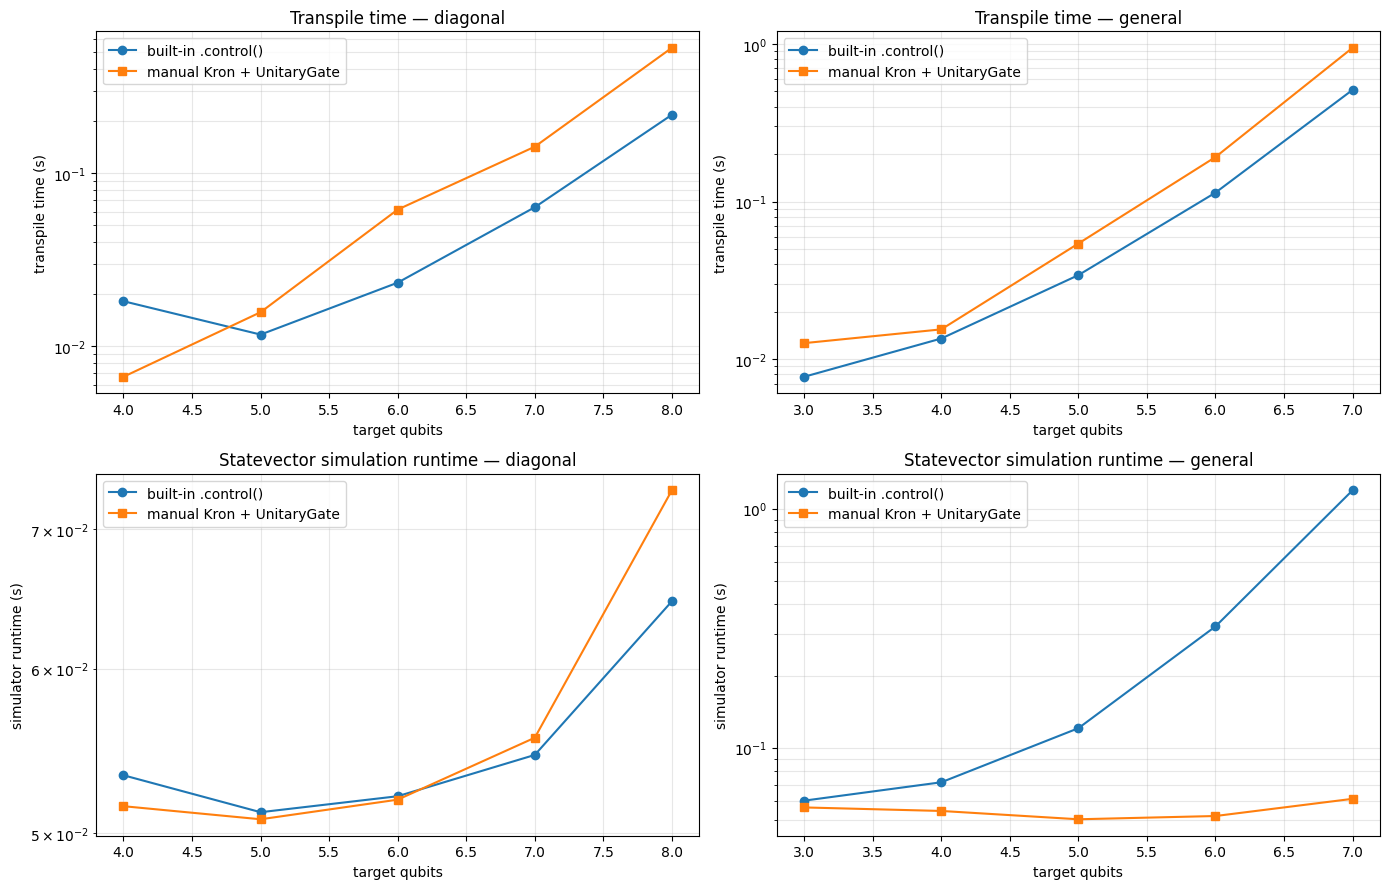

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, case in zip(axes[0], ['diagonal', 'general']):
    sub = df[df['case'] == case]
    x   = sub['n_target_qubits']
    ax.plot(x, sub['builtin_transp_s'], 'o-', label='built-in .control()')
    ax.plot(x, sub['manual_transp_s'],  's-', label='manual Kron + UnitaryGate')
    ax.set_yscale('log')
    ax.set_xlabel('target qubits')
    ax.set_ylabel('transpile time (s)')
    ax.set_title(f'Transpile time — {case}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

for ax, case in zip(axes[1], ['diagonal', 'general']):
    sub = df[df['case'] == case]
    x   = sub['n_target_qubits']
    ax.plot(x, sub['builtin_runtime_s'], 'o-', label='built-in .control()')
    ax.plot(x, sub['manual_runtime_s'],  's-', label='manual Kron + UnitaryGate')
    ax.set_yscale('log')
    ax.set_xlabel('target qubits')
    ax.set_ylabel('simulator runtime (s)')
    ax.set_title(f'Statevector simulation runtime — {case}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

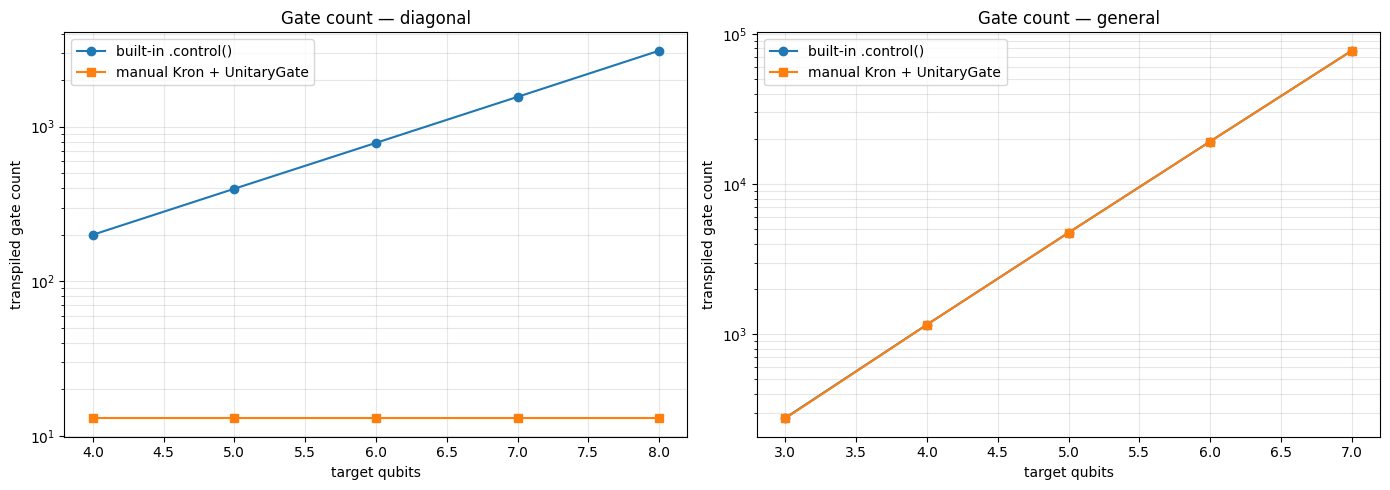

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, case in zip(axes, ['diagonal', 'general']):
    sub = df[df['case'] == case]
    x   = sub['n_target_qubits']
    ax.plot(x, sub['builtin_gates'], 'o-', label='built-in .control()')
    ax.plot(x, sub['manual_gates'],  's-', label='manual Kron + UnitaryGate')
    ax.set_yscale('log')
    ax.set_xlabel('target qubits')
    ax.set_ylabel('transpiled gate count')
    ax.set_title(f'Gate count — {case}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()